# 05 - Time Series, Tabular, Speech, and Document-Image Augmentation

This notebook covers four more modalities from the assignment:

- time series
- tabular data
- speech
- document images

To keep the notebook portable in Colab, each section uses either synthetic data or a compact handcrafted dataset.


In [1]:
# Colab setup
%pip -q install -U tensorflow scikit-learn pandas matplotlib pillow librosa opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires p

In [1]:
import os
import cv2
import math
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


## Part A - Time-series augmentation and classification

We generate two classes of sequences:

- noisy sine waves
- noisy square waves

Then we compare a baseline 1D CNN against the same model trained with augmented time-series windows.


In [2]:
def make_wave_dataset(n=800, length=128):
    X, y = [], []
    t = np.linspace(0, 1, length)
    for _ in range(n):
        phase = np.random.uniform(0, 2 * np.pi)
        freq = np.random.uniform(2, 5)
        sine = np.sin(2 * np.pi * freq * t + phase) + np.random.normal(0, 0.1, length)
        square = np.sign(np.sin(2 * np.pi * freq * t + phase)) + np.random.normal(0, 0.1, length)
        X.append(sine.astype("float32"))
        y.append(0)
        X.append(square.astype("float32"))
        y.append(1)
    X = np.array(X)[..., None]
    y = np.array(y)
    return X, y

def augment_timeseries(x):
    x = x.copy()
    x = x * np.random.uniform(0.8, 1.2)
    x = x + np.random.normal(0, 0.05, size=x.shape)
    shift = np.random.randint(-6, 7)
    x = np.roll(x, shift, axis=0)
    return x.astype("float32")

X_ts, y_ts = make_wave_dataset()
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_ts, y_ts, test_size=0.25, random_state=SEED, stratify=y_ts)

Xts_aug = np.stack([augment_timeseries(x) for x in Xt_train])


In [3]:
def build_ts_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(128, 1)),
            layers.Conv1D(16, 5, activation="relu", padding="same"),
            layers.MaxPool1D(),
            layers.Conv1D(32, 5, activation="relu", padding="same"),
            layers.GlobalAveragePooling1D(),
            layers.Dropout(0.25),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cb = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)]

ts_base = build_ts_model()
ts_aug = build_ts_model()

hist_ts_base = ts_base.fit(Xt_train, yt_train, validation_split=0.2, epochs=8, batch_size=64, verbose=1, callbacks=cb)

Xt_train_mix = np.concatenate([Xt_train, Xts_aug], axis=0)
yt_train_mix = np.concatenate([yt_train, yt_train], axis=0)

hist_ts_aug = ts_aug.fit(Xt_train_mix, yt_train_mix, validation_split=0.2, epochs=8, batch_size=64, verbose=1, callbacks=cb)

ts_base_acc = ts_base.evaluate(Xt_test, yt_test, verbose=0)[1]
ts_aug_acc = ts_aug.evaluate(Xt_test, yt_test, verbose=0)[1]

pd.DataFrame([
    {"experiment": "timeseries_baseline", "test_acc": ts_base_acc},
    {"experiment": "timeseries_augmented", "test_acc": ts_aug_acc},
])


Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5292 - loss: 0.6740 - val_accuracy: 0.5167 - val_loss: 0.6488
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5302 - loss: 0.6450 - val_accuracy: 0.5167 - val_loss: 0.6198
Epoch 3/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6052 - loss: 0.6116 - val_accuracy: 0.5250 - val_loss: 0.5854
Epoch 4/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7000 - loss: 0.5800 - val_accuracy: 0.9958 - val_loss: 0.5423
Epoch 5/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8813 - loss: 0.5218 - val_accuracy: 1.0000 - val_loss: 0.4839
Epoch 6/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9573 - loss: 0.4664 - val_accuracy: 1.0000 - val_loss: 0.4199
Epoch 7/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9875 - loss: 0.4036 - val_accuracy: 1.0000 - val_loss: 0.3519
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5141 - loss: 0.6576 - val_accuracy: 0.5125 - val_loss:

,experiment,test_acc
0,timeseries_baseline,1.0
1,timeseries_augmented,0.5


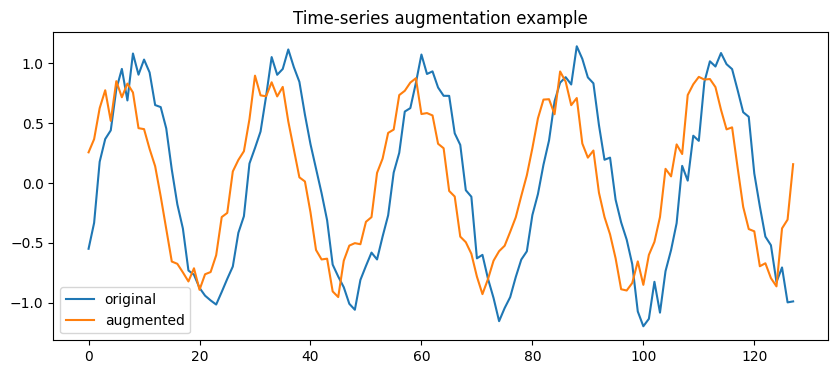

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(Xt_train[0].squeeze(), label="original")
plt.plot(Xts_aug[0].squeeze(), label="augmented")
plt.title("Time-series augmentation example")
plt.legend()
plt.show()


## Part B - Tabular augmentation and classification

For tabular data, augmentation is tricky because random perturbations can destroy feature relationships.
A safer lightweight demo is interpolation plus mild feature noise.


In [5]:
X_tab, y_tab = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    weights=[0.65, 0.35],
    class_sep=1.2,
    random_state=SEED,
)

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab, y_tab, test_size=0.25, random_state=SEED, stratify=y_tab
)

scaler = StandardScaler()
X_train_tab_s = scaler.fit_transform(X_train_tab)
X_test_tab_s = scaler.transform(X_test_tab)

minority = X_train_tab_s[y_train_tab == 1]
augmented_tab = []
for _ in range(len(minority)):
    a, b = minority[np.random.randint(0, len(minority), size=2)]
    lam = np.random.uniform(0.2, 0.8)
    synthetic = lam * a + (1 - lam) * b + np.random.normal(0, 0.03, size=a.shape)
    augmented_tab.append(synthetic)

augmented_tab = np.array(augmented_tab)
y_aug_tab = np.ones(len(augmented_tab), dtype=int)

X_train_tab_aug = np.concatenate([X_train_tab_s, augmented_tab], axis=0)
y_train_tab_aug = np.concatenate([y_train_tab, y_aug_tab], axis=0)

tab_base = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=150, random_state=SEED)
tab_aug = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=150, random_state=SEED)

tab_base.fit(X_train_tab_s, y_train_tab)
tab_aug.fit(X_train_tab_aug, y_train_tab_aug)

base_tab_acc = accuracy_score(y_test_tab, tab_base.predict(X_test_tab_s))
aug_tab_acc = accuracy_score(y_test_tab, tab_aug.predict(X_test_tab_s))

pd.DataFrame([
    {"experiment": "tabular_baseline", "test_acc": base_tab_acc},
    {"experiment": "tabular_augmented", "test_acc": aug_tab_acc},
])


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


,experiment,test_acc
0,tabular_baseline,0.973333
1,tabular_augmented,0.962667


## Part C - Speech augmentation and classification

Instead of downloading a speech corpus, we generate two classes of toy audio signals:

- low-frequency tones
- high-frequency tones

We convert them into small spectrograms and train a tiny CNN.


In [6]:
def tone(freq, sr=8000, duration=1.0):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return np.sin(2 * np.pi * freq * t).astype("float32")

def augment_audio(x):
    x = x.copy()
    x = np.roll(x, np.random.randint(-200, 201))
    x = x + np.random.normal(0, 0.03, size=x.shape)
    x = x * np.random.uniform(0.8, 1.2)
    return np.clip(x, -1.0, 1.0).astype("float32")

def to_spectrogram(signal, frame=256, hop=128):
    spec = tf.signal.stft(signal, frame_length=frame, frame_step=hop)
    spec = tf.abs(spec)
    spec = tf.math.log(spec + 1e-6)
    spec = tf.image.resize(spec[..., None], (64, 64))
    return spec.numpy()

audio_signals = []
audio_labels = []
for _ in range(400):
    audio_signals.append(tone(np.random.uniform(180, 260)))
    audio_labels.append(0)
    audio_signals.append(tone(np.random.uniform(520, 700)))
    audio_labels.append(1)

audio_signals = np.array(audio_signals)
audio_labels = np.array(audio_labels)

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    audio_signals, audio_labels, test_size=0.25, random_state=SEED, stratify=audio_labels
)

Xa_train_spec = np.stack([to_spectrogram(x) for x in Xa_train])
Xa_test_spec = np.stack([to_spectrogram(x) for x in Xa_test])

Xa_train_aug_spec = np.stack([to_spectrogram(augment_audio(x)) for x in Xa_train])


In [7]:
def build_audio_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(64, 64, 1)),
            layers.Conv2D(16, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.Conv2D(32, 3, activation="relu", padding="same"),
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.25),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

audio_base = build_audio_model()
audio_aug = build_audio_model()

hist_audio_base = audio_base.fit(
    Xa_train_spec, ya_train, validation_split=0.2, epochs=8, batch_size=32, verbose=1, callbacks=cb
)

Xa_train_audio_mix = np.concatenate([Xa_train_spec, Xa_train_aug_spec], axis=0)
ya_train_audio_mix = np.concatenate([ya_train, ya_train], axis=0)

hist_audio_aug = audio_aug.fit(
    Xa_train_audio_mix, ya_train_audio_mix, validation_split=0.2, epochs=8, batch_size=32, verbose=1, callbacks=cb
)

audio_base_acc = audio_base.evaluate(Xa_test_spec, ya_test, verbose=0)[1]
audio_aug_acc = audio_aug.evaluate(Xa_test_spec, ya_test, verbose=0)[1]

pd.DataFrame([
    {"experiment": "speech_baseline", "test_acc": audio_base_acc},
    {"experiment": "speech_augmented", "test_acc": audio_aug_acc},
])


Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5375 - loss: 0.7014 - val_accuracy: 0.5500 - val_loss: 0.6621
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.5229 - loss: 0.7003 - val_accuracy: 0.5500 - val_loss: 0.6565
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.5073 - loss: 0.7267 - val_accuracy: 0.5500 - val_loss: 0.6854
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.5708 - loss: 0.6823 - val_accuracy: 0.7667 - val_loss: 0.6756


,experiment,test_acc
0,speech_baseline,0.5
1,speech_augmented,0.5


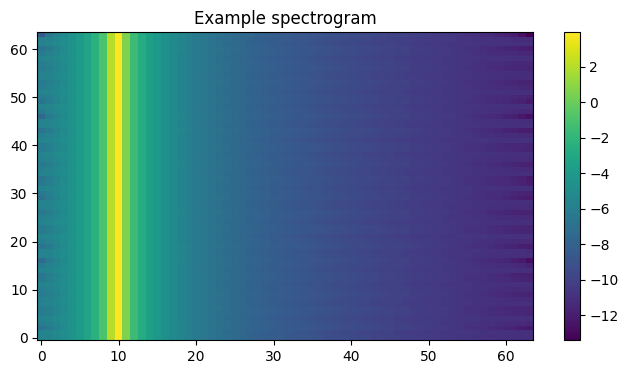

In [8]:
plt.figure(figsize=(8, 4))
plt.imshow(Xa_train_spec[0].squeeze(), aspect="auto", origin="lower")
plt.title("Example spectrogram")
plt.colorbar()
plt.show()


## Part D - Document-image augmentation and classification

We synthesize two simple document templates:

- invoice-like layout
- memo-like layout

Then we apply scan-like corruption such as blur, rotation, and noise.


In [9]:
def draw_document(kind="invoice", size=(180, 180)):
    img = Image.new("L", size, color=255)
    draw = ImageDraw.Draw(img)

    if kind == "invoice":
        draw.rectangle((10, 10, 170, 35), outline=0, width=2)
        draw.text((15, 15), "INVOICE", fill=0)
        for y in [55, 80, 105, 130]:
            draw.line((15, y, 165, y), fill=0, width=1)
        draw.rectangle((120, 145, 165, 165), outline=0, width=2)
    else:
        draw.text((15, 15), "MEMO", fill=0)
        for y in [45, 65, 85, 105, 125, 145]:
            draw.line((15, y, 160, y), fill=0, width=1)

    return np.array(img, dtype="float32") / 255.0

def augment_document(img):
    pil = Image.fromarray((img * 255).astype("uint8"))
    angle = np.random.uniform(-7, 7)
    pil = pil.rotate(angle, fillcolor=255)
    pil = pil.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0.0, 1.2)))
    arr = np.array(pil, dtype="float32") / 255.0
    arr = arr + np.random.normal(0, 0.03, size=arr.shape)
    return np.clip(arr, 0.0, 1.0)

doc_imgs = []
doc_labels = []
for _ in range(500):
    doc_imgs.append(draw_document("invoice"))
    doc_labels.append(0)
    doc_imgs.append(draw_document("memo"))
    doc_labels.append(1)

doc_imgs = np.array(doc_imgs)[..., None]
doc_labels = np.array(doc_labels)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    doc_imgs, doc_labels, test_size=0.25, random_state=SEED, stratify=doc_labels
)

Xd_train_aug = np.stack([augment_document(x.squeeze()) for x in Xd_train])[..., None]


In [10]:
def build_doc_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(180, 180, 1)),
            layers.Conv2D(16, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.Conv2D(32, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.GlobalAveragePooling2D(),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

doc_base = build_doc_model()
doc_aug = build_doc_model()

hist_doc_base = doc_base.fit(
    Xd_train, yd_train, validation_split=0.2, epochs=6, batch_size=32, verbose=1, callbacks=cb
)

Xd_train_mix = np.concatenate([Xd_train, Xd_train_aug], axis=0)
yd_train_mix = np.concatenate([yd_train, yd_train], axis=0)

hist_doc_aug = doc_aug.fit(
    Xd_train_mix, yd_train_mix, validation_split=0.2, epochs=6, batch_size=32, verbose=1, callbacks=cb
)

doc_base_acc = doc_base.evaluate(Xd_test, yd_test, verbose=0)[1]
doc_aug_acc = doc_aug.evaluate(Xd_test, yd_test, verbose=0)[1]

pd.DataFrame([
    {"experiment": "document_baseline", "test_acc": doc_base_acc},
    {"experiment": "document_augmented", "test_acc": doc_aug_acc},
])


Epoch 1/6
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5467 - loss: 0.6865 - val_accuracy: 0.4800 - val_loss: 0.6941
Epoch 2/6
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 712ms/step - accuracy: 0.5767 - loss: 0.6788 - val_accuracy: 0.4800 - val_loss: 0.6662
Epoch 1/6
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 700ms/step - accuracy: 0.5625 - loss: 0.6950 - val_accuracy: 0.7167 - val_loss: 0.6828
Epoch 2/6
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 690ms/step - accuracy: 0.8142 - loss: 0.6445 - val_accuracy: 0.5900 - val_loss: 0.6540


,experiment,test_acc
0,document_baseline,0.5
1,document_augmented,1.0


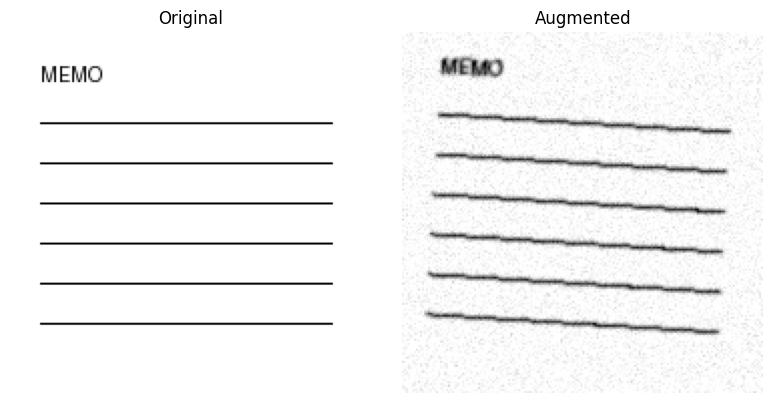

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Xd_train[0].squeeze(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(Xd_train_aug[0].squeeze(), cmap="gray")
axes[1].set_title("Augmented")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Summary

This notebook is deliberately broad. The point is to show that augmentation is not just a computer-vision trick.

- time series: jitter, scaling, shifting
- tabular: careful interpolation and noise
- speech: shift, noise, spectrogram-based learning
- document images: blur, rotation, scan artifacts

For the video, do not linger forever on every metric cell. Show one or two examples per modality, explain the intuition, then move on before the runtime demons awaken.
